In [1]:
# ============================================
# TASK 20: BACKTESTING EVALUATION
# ============================================
# Tests both models against 4 benchmarks using
# 2023 quarterly snapshots with 6-month holding periods.
#
# Benchmarks:
#   1. Random Portfolio (10 random SGX stocks)
#   2. STI Index (buy-and-hold)
#   3. Momentum Strategy (top 10 by 6M trailing return)
#   4. High-Dividend Strategy (top 10 by dividend yield)
#
# Metrics:
#   - Mean 6-Month Return
#   - Win Rate vs STI
#   - Maximum Drawdown
#   - Volatility
#   - Precision@5
#   - Sharpe Ratio
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import warnings
from scipy import stats
from datetime import datetime, timedelta
import random

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

print("=" * 60)
print("TASK 20: BACKTESTING EVALUATION")
print("=" * 60)
print("\n✓ Libraries loaded")

TASK 20: BACKTESTING EVALUATION

✓ Libraries loaded


In [2]:
# ============================================
# STEP 1: LOAD ALL REQUIRED DATA AND MODELS
# ============================================

print("\n[Step 1] Loading data and models...")

# --- Models ---
rf_model = joblib.load('data/ml/rf_model.joblib')
print("✓ Random Forest model loaded")

feature_cols = pd.read_csv('data/ml/feature_columns.csv')['Feature'].tolist()
print(f"✓ Feature columns loaded ({len(feature_cols)} features)")

# --- Snapshots (quarterly data with labels) ---
train_df = pd.read_csv('data/ml/train_data.csv', parse_dates=['Snapshot_Date'])
val_df   = pd.read_csv('data/ml/val_data.csv',   parse_dates=['Snapshot_Date'])
test_df  = pd.read_csv('data/ml/test_data.csv',  parse_dates=['Snapshot_Date'])

# Combine all snapshots — backtesting uses 2023 quarters
all_snapshots = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_snapshots = all_snapshots.sort_values('Snapshot_Date').reset_index(drop=True)

# Filter to 2023 snapshots only
snapshots_2023 = all_snapshots[
    all_snapshots['Snapshot_Date'].dt.year == 2023
].copy()

quarters_2023 = sorted(snapshots_2023['Snapshot_Date'].unique())
print(f"\n✓ 2023 quarterly snapshots found: {len(quarters_2023)}")
for q in quarters_2023:
    n = len(snapshots_2023[snapshots_2023['Snapshot_Date'] == q])
    print(f"   {pd.Timestamp(q).date()} — {n} stocks")

# --- Price data (daily OHLCV for all stocks) ---
price_data = {}
price_dir = 'data/prices/'
price_files = [f for f in os.listdir(price_dir) if f.endswith('.csv')]

for fname in price_files:
    ticker_clean = fname.replace('.csv', '')
    ticker = ticker_clean + '.SI'
    try:
        df = pd.read_csv(os.path.join(price_dir, fname), index_col=0,
                         parse_dates=True)
        # Remove timezone if present
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)
        price_data[ticker] = df
    except Exception:
        pass

print(f"\n✓ Price data loaded for {len(price_data)} stocks")

# --- Stock universe ---
universe = pd.read_csv('data/stock_universe_clean.csv')
all_tickers = universe['Ticker'].tolist()
print(f"✓ Stock universe: {len(all_tickers)} stocks")

# --- STI Index proxy ---
# Try to load STI data; if not available, use equal-weight universe average
sti_path = 'data/prices/STI.csv'
sti_available = os.path.exists(sti_path)
if sti_available:
    sti_df = pd.read_csv(sti_path, index_col=0, parse_dates=True)
    if sti_df.index.tz is not None:
        sti_df.index = sti_df.index.tz_localize(None)
    print("✓ STI Index price data loaded")
else:
    print("⚠ STI Index file not found — will use equal-weight universe average as proxy")

print("\n✓ All data loaded successfully")


[Step 1] Loading data and models...
✓ Random Forest model loaded
✓ Feature columns loaded (29 features)

✓ 2023 quarterly snapshots found: 4
   2023-03-31 — 55 stocks
   2023-06-30 — 55 stocks
   2023-09-29 — 55 stocks
   2023-12-29 — 55 stocks

✓ Price data loaded for 55 stocks
✓ Stock universe: 55 stocks
⚠ STI Index file not found — will use equal-weight universe average as proxy

✓ All data loaded successfully


In [3]:
# ============================================
# STEP 2: DEFINE HELPER FUNCTIONS
# ============================================

print("\n[Step 2] Defining helper functions...")

# ---- Factor Scoring ----
def compute_factor_score(row):
    """
    Factor-based scoring model (40% growth, 40% quality, 20% risk).
    Identical to the production model in FYP_Development.ipynb.
    """
    score = 0

    # GROWTH (40%)
    if pd.notna(row.get('Revenue_Growth')):
        rev = np.clip(row['Revenue_Growth'], -0.5, 1.0)
        score += ((rev + 0.5) / 1.5 * 100) * 0.20
    if pd.notna(row.get('EPS')):
        eps = np.clip(row['EPS'], -1, 5)
        score += ((eps + 1) / 6 * 100) * 0.10
    if pd.notna(row.get('Return_6M')):
        mom = np.clip(row['Return_6M'], -0.5, 1.0)
        score += ((mom + 0.5) / 1.5 * 100) * 0.10

    # QUALITY (40%)
    if pd.notna(row.get('ROE')):
        roe = np.clip(row['ROE'], -0.2, 0.4)
        score += ((roe + 0.2) / 0.6 * 100) * 0.15
    if pd.notna(row.get('Profit_Margin')):
        margin = np.clip(row['Profit_Margin'], -0.2, 0.5)
        score += ((margin + 0.2) / 0.7 * 100) * 0.10
    if pd.notna(row.get('Debt_to_Equity')):
        debt = np.clip(row['Debt_to_Equity'], 0, 300)
        score += ((300 - debt) / 300 * 100) * 0.10
    if pd.notna(row.get('Market_Cap')):
        mcap_log = np.log10(max(row['Market_Cap'], 1e6))
        score += np.clip((mcap_log - 6) / 5.2 * 100, 0, 100) * 0.05

    # RISK (20%)
    if pd.notna(row.get('Volatility')) and row['Volatility'] > 0:
        vol = np.clip(row['Volatility'], 0.1, 0.8)
        score += ((0.8 - vol) / 0.7 * 100) * 0.10
    if pd.notna(row.get('Max_Drawdown')):
        dd = np.clip(row['Max_Drawdown'], -0.6, 0)
        score += ((dd + 0.6) / 0.6 * 100) * 0.10

    return score


# ---- Sector one-hot encoding for ML ----
def prepare_ml_features(df, feature_cols):
    """Add sector dummies and align to training feature set."""
    df = df.copy()
    if 'Sector' in df.columns:
        dummies = pd.get_dummies(df['Sector'], prefix='Sector')
        df = pd.concat([df, dummies], axis=1)
    for col in feature_cols:
        if col.startswith('Sector_') and col not in df.columns:
            df[col] = 0
    X = df[feature_cols].copy()
    X = X.fillna(X.median())
    return X


# ---- 6-month forward return from price data ----
def get_forward_return(ticker, start_date, holding_days=126):
    """
    Calculate the actual 6-month (≈126 trading days) return
    for a stock starting from start_date.

    Returns float or NaN if data unavailable.
    """
    if ticker not in price_data:
        return np.nan

    df = price_data[ticker]
    price_col = 'Price' if 'Price' in df.columns else 'Close'
    if price_col not in df.columns:
        return np.nan

    # Find the closest available date on or after start_date
    start_date = pd.Timestamp(start_date)
    available = df.index[df.index >= start_date]
    if len(available) == 0:
        return np.nan

    entry_date = available[0]
    entry_price = df.loc[entry_date, price_col]

    # Find exit date (~126 trading days later)
    future_dates = df.index[df.index > entry_date]
    if len(future_dates) < holding_days:
        # Use last available price if holding period extends beyond data
        exit_date = df.index[-1]
    else:
        exit_date = future_dates[holding_days - 1]

    exit_price = df.loc[exit_date, price_col]

    if pd.isna(entry_price) or pd.isna(exit_price) or entry_price == 0:
        return np.nan

    return (exit_price - entry_price) / entry_price


# ---- Daily return series for a portfolio ----
def get_portfolio_daily_returns(tickers, start_date, holding_days=126):
    """
    Get equal-weight portfolio daily returns for a list of tickers
    over a 6-month holding period.

    Returns a Series of daily portfolio returns.
    """
    start_date = pd.Timestamp(start_date)
    all_series = []

    for ticker in tickers:
        if ticker not in price_data:
            continue
        df = price_data[ticker]
        price_col = 'Price' if 'Price' in df.columns else 'Close'
        if price_col not in df.columns:
            continue

        available = df.index[df.index >= start_date]
        if len(available) < 2:
            continue

        entry_date = available[0]
        future_dates = df.index[df.index > entry_date]

        if len(future_dates) == 0:
            continue

        end_idx = min(holding_days - 1, len(future_dates) - 1)
        exit_date = future_dates[end_idx]

        series = df.loc[entry_date:exit_date, price_col]
        daily_ret = series.pct_change().dropna()
        all_series.append(daily_ret)

    if not all_series:
        return pd.Series(dtype=float)

    combined = pd.concat(all_series, axis=1)
    portfolio_returns = combined.mean(axis=1)
    return portfolio_returns


# ---- Risk metrics from daily return series ----
def compute_risk_metrics(daily_returns):
    """
    Compute Sharpe ratio, max drawdown, and annualised volatility
    from a daily return series.
    """
    if len(daily_returns) == 0:
        return {'sharpe': np.nan, 'max_drawdown': np.nan, 'volatility': np.nan}

    # Annualised Sharpe (risk-free ≈ 0 for simplicity)
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    # Max drawdown from cumulative returns
    cumulative = (1 + daily_returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdowns = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdowns.min()

    return {
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'volatility': ann_vol
    }


# ---- STI benchmark return ----
def get_sti_return(start_date, holding_days=126):
    """Get STI return over the holding period."""
    start_date = pd.Timestamp(start_date)
    if sti_available:
        return get_forward_return('^STI', start_date, holding_days)

    # Fallback: equal-weight average of all tickers in universe
    returns = [get_forward_return(t, start_date, holding_days)
               for t in all_tickers]
    valid = [r for r in returns if not np.isnan(r)]
    return np.mean(valid) if valid else np.nan


print("✓ Helper functions defined:")
print("  - compute_factor_score()")
print("  - prepare_ml_features()")
print("  - get_forward_return()")
print("  - get_portfolio_daily_returns()")
print("  - compute_risk_metrics()")
print("  - get_sti_return()")


[Step 2] Defining helper functions...
✓ Helper functions defined:
  - compute_factor_score()
  - prepare_ml_features()
  - get_forward_return()
  - get_portfolio_daily_returns()
  - compute_risk_metrics()
  - get_sti_return()


In [4]:
# ============================================
# STEP 3: RUN BACKTESTING FOR EACH 2023 QUARTER
# ============================================

print("\n[Step 3] Running backtesting across 2023 quarters...")
print("=" * 60)

HOLDING_DAYS = 126   # ~6 months of trading days
TOP_N = 10           # Recommendation list size
TOP_K = 5            # Precision@K

quarterly_results = []

for snapshot_date in quarters_2023:
    ts = pd.Timestamp(snapshot_date)
    quarter_num = (ts.month - 1) // 3 + 1
    quarter_label = f"{ts.year} Q{quarter_num}"
    print(f"\n--- {quarter_label} ({pd.Timestamp(snapshot_date).date()}) ---")

    # Get snapshot data for this quarter
    q_data = snapshots_2023[
        snapshots_2023['Snapshot_Date'] == snapshot_date
    ].copy()
    print(f"  Stocks available: {len(q_data)}")

    if len(q_data) < TOP_N:
        print(f"  ⚠ Fewer than {TOP_N} stocks — skipping quarter")
        continue

    tickers_this_quarter = q_data['Ticker'].tolist()

    # ---- FACTOR MODEL: Top 10 by factor score ----
    q_data['Factor_Score'] = q_data.apply(compute_factor_score, axis=1)
    factor_top10 = q_data.nlargest(TOP_N, 'Factor_Score')['Ticker'].tolist()

    # ---- ML MODEL: Top 10 by ML probability ----
    X_q = prepare_ml_features(q_data, feature_cols)
    q_data['ML_Probability'] = rf_model.predict_proba(X_q)[:, 1]
    ml_top10 = q_data.nlargest(TOP_N, 'ML_Probability')['Ticker'].tolist()

    # ---- HYBRID: Stocks in both Top 10 (High Confidence) ----
    hybrid_tickers = list(set(factor_top10) & set(ml_top10))
    if len(hybrid_tickers) < 3:
        # Fall back to union ranked by combined score
        q_data['Factor_Norm'] = (
            (q_data['Factor_Score'] - q_data['Factor_Score'].min()) /
            (q_data['Factor_Score'].max() - q_data['Factor_Score'].min() + 1e-9)
        )
        q_data['Combined_Score'] = (
            q_data['Factor_Norm'] + q_data['ML_Probability']) / 2
        hybrid_tickers = q_data.nlargest(TOP_N, 'Combined_Score')['Ticker'].tolist()

    # ---- BENCHMARK 1: Random Portfolio ----
    available_for_random = [t for t in tickers_this_quarter
                            if t not in factor_top10]
    if len(available_for_random) >= TOP_N:
        random_tickers = random.sample(available_for_random, TOP_N)
    else:
        random_tickers = random.sample(tickers_this_quarter, TOP_N)

    # ---- BENCHMARK 2: STI Index ----
    sti_return = get_sti_return(snapshot_date, HOLDING_DAYS)

    # ---- BENCHMARK 3: Momentum Strategy ----
    # Top 10 by 6-month trailing return (Return_6M feature)
    if 'Return_6M' in q_data.columns:
        momentum_top10 = q_data.nlargest(TOP_N, 'Return_6M')['Ticker'].tolist()
    else:
        momentum_top10 = random.sample(tickers_this_quarter, TOP_N)

    # ---- BENCHMARK 4: High-Dividend Strategy ----
    if 'Dividend_Yield' in q_data.columns:
        div_data = q_data.dropna(subset=['Dividend_Yield'])
        if len(div_data) >= TOP_N:
            dividend_top10 = div_data.nlargest(
                TOP_N, 'Dividend_Yield')['Ticker'].tolist()
        else:
            dividend_top10 = div_data['Ticker'].tolist()
            dividend_top10 += random.sample(
                [t for t in tickers_this_quarter if t not in dividend_top10],
                TOP_N - len(dividend_top10))
    else:
        dividend_top10 = random.sample(tickers_this_quarter, TOP_N)

    # ---- COMPUTE FORWARD RETURNS ----
    def portfolio_return(tickers):
        """Equal-weight mean 6-month return for a list of tickers."""
        returns = [get_forward_return(t, snapshot_date, HOLDING_DAYS)
                   for t in tickers]
        valid = [r for r in returns if not np.isnan(r)]
        return np.mean(valid) if valid else np.nan

    factor_ret   = portfolio_return(factor_top10)
    ml_ret       = portfolio_return(ml_top10)
    hybrid_ret   = portfolio_return(hybrid_tickers)
    random_ret   = portfolio_return(random_tickers)
    momentum_ret = portfolio_return(momentum_top10)
    dividend_ret = portfolio_return(dividend_top10)

    # ---- WIN RATE vs STI ----
    def win_rate(tickers, sti_ret):
        """% of stocks that beat STI return."""
        if np.isnan(sti_ret):
            return np.nan
        returns = [get_forward_return(t, snapshot_date, HOLDING_DAYS)
                   for t in tickers]
        valid = [r for r in returns if not np.isnan(r)]
        if not valid:
            return np.nan
        return sum(1 for r in valid if r > sti_ret) / len(valid)

    factor_wr   = win_rate(factor_top10,   sti_return)
    ml_wr       = win_rate(ml_top10,       sti_return)
    hybrid_wr   = win_rate(hybrid_tickers, sti_return)
    random_wr   = win_rate(random_tickers, sti_return)
    momentum_wr = win_rate(momentum_top10, sti_return)
    dividend_wr = win_rate(dividend_top10, sti_return)

    # ---- RISK METRICS (from daily returns) ----
    def risk_metrics(tickers):
        daily_rets = get_portfolio_daily_returns(
            tickers, snapshot_date, HOLDING_DAYS)
        return compute_risk_metrics(daily_rets)

    factor_risk   = risk_metrics(factor_top10)
    ml_risk       = risk_metrics(ml_top10)
    hybrid_risk   = risk_metrics(hybrid_tickers)
    random_risk   = risk_metrics(random_tickers)
    momentum_risk = risk_metrics(momentum_top10)
    dividend_risk = risk_metrics(dividend_top10)

    # ---- PRECISION@5 ----
    # Fraction of top-5 picks that are in the actual top quartile
    # (top 25% performers ex-post)
    actual_returns = {}
    for t in tickers_this_quarter:
        r = get_forward_return(t, snapshot_date, HOLDING_DAYS)
        if not np.isnan(r):
            actual_returns[t] = r

    if len(actual_returns) > 0:
        threshold = np.percentile(list(actual_returns.values()), 75)

        def precision_at_k(tickers, k=TOP_K):
            top_k = tickers[:k]
            hits = sum(1 for t in top_k
                       if t in actual_returns and actual_returns[t] >= threshold)
            return hits / k

        factor_p5   = precision_at_k(factor_top10)
        ml_p5       = precision_at_k(ml_top10)
        hybrid_p5   = precision_at_k(hybrid_tickers)
        random_p5   = precision_at_k(random_tickers)
        momentum_p5 = precision_at_k(momentum_top10)
        dividend_p5 = precision_at_k(dividend_top10)
    else:
        factor_p5 = ml_p5 = hybrid_p5 = np.nan
        random_p5 = momentum_p5 = dividend_p5 = np.nan

    # ---- STORE RESULTS ----
    row = {
        'Quarter':          quarter_label,
        'Snapshot_Date':    pd.Timestamp(snapshot_date).date(),

        # Returns
        'Factor_Return':    factor_ret,
        'ML_Return':        ml_ret,
        'Hybrid_Return':    hybrid_ret,
        'STI_Return':       sti_return,
        'Random_Return':    random_ret,
        'Momentum_Return':  momentum_ret,
        'Dividend_Return':  dividend_ret,

        # Win Rates
        'Factor_WinRate':   factor_wr,
        'ML_WinRate':       ml_wr,
        'Hybrid_WinRate':   hybrid_wr,
        'Random_WinRate':   random_wr,
        'Momentum_WinRate': momentum_wr,
        'Dividend_WinRate': dividend_wr,

        # Sharpe Ratios
        'Factor_Sharpe':    factor_risk['sharpe'],
        'ML_Sharpe':        ml_risk['sharpe'],
        'Hybrid_Sharpe':    hybrid_risk['sharpe'],
        'Random_Sharpe':    random_risk['sharpe'],
        'Momentum_Sharpe':  momentum_risk['sharpe'],
        'Dividend_Sharpe':  dividend_risk['sharpe'],

        # Max Drawdowns
        'Factor_MaxDD':     factor_risk['max_drawdown'],
        'ML_MaxDD':         ml_risk['max_drawdown'],
        'Hybrid_MaxDD':     hybrid_risk['max_drawdown'],
        'Random_MaxDD':     random_risk['max_drawdown'],
        'Momentum_MaxDD':   momentum_risk['max_drawdown'],
        'Dividend_MaxDD':   dividend_risk['max_drawdown'],

        # Volatility
        'Factor_Vol':       factor_risk['volatility'],
        'ML_Vol':           ml_risk['volatility'],
        'Hybrid_Vol':       hybrid_risk['volatility'],
        'Random_Vol':       random_risk['volatility'],
        'Momentum_Vol':     momentum_risk['volatility'],
        'Dividend_Vol':     dividend_risk['volatility'],

        # Precision@5
        'Factor_P5':        factor_p5,
        'ML_P5':            ml_p5,
        'Hybrid_P5':        hybrid_p5,
        'Random_P5':        random_p5,
        'Momentum_P5':      momentum_p5,
        'Dividend_P5':      dividend_p5,
    }
    quarterly_results.append(row)

    # Quick print
    print(f"  Returns  — Factor: {factor_ret:.1%}  ML: {ml_ret:.1%}  "
          f"Hybrid: {hybrid_ret:.1%}  STI: {sti_return:.1%}  "
          f"Random: {random_ret:.1%}")
    print(f"  WinRate  — Factor: {factor_wr:.0%}   ML: {ml_wr:.0%}   "
          f"Hybrid: {hybrid_wr:.0%}")
    print(f"  Prec@5   — Factor: {factor_p5:.2f}   ML: {ml_p5:.2f}   "
          f"Hybrid: {hybrid_p5:.2f}")

results_df = pd.DataFrame(quarterly_results)
print(f"\n✓ Backtesting complete — {len(results_df)} quarters processed")


[Step 3] Running backtesting across 2023 quarters...

--- 2023 Q1 (2023-03-31) ---
  Stocks available: 55
  Returns  — Factor: 4.6%  ML: 5.6%  Hybrid: 10.6%  STI: -1.2%  Random: -8.7%
  WinRate  — Factor: 80%   ML: 50%   Hybrid: 90%
  Prec@5   — Factor: 0.20   ML: 0.40   Hybrid: 0.60

--- 2023 Q2 (2023-06-30) ---
  Stocks available: 55
  Returns  — Factor: 1.5%  ML: 0.2%  Hybrid: 11.8%  STI: 3.3%  Random: 2.2%
  WinRate  — Factor: 60%   ML: 40%   Hybrid: 70%
  Prec@5   — Factor: 0.20   ML: 0.20   Hybrid: 0.20

--- 2023 Q3 (2023-09-29) ---
  Stocks available: 55
  Returns  — Factor: 6.3%  ML: -0.0%  Hybrid: 7.9%  STI: -2.6%  Random: -9.8%
  WinRate  — Factor: 80%   ML: 60%   Hybrid: 90%
  Prec@5   — Factor: 0.60   ML: 0.40   Hybrid: 1.00

--- 2023 Q4 (2023-12-29) ---
  Stocks available: 55
  Returns  — Factor: 8.0%  ML: -2.8%  Hybrid: 14.6%  STI: -3.8%  Random: -9.4%
  WinRate  — Factor: 80%   ML: 50%   Hybrid: 70%
  Prec@5   — Factor: 0.60   ML: 0.60   Hybrid: 0.60

✓ Backtesting comp

In [5]:
# ============================================
# STEP 4: SUMMARY STATISTICS & HYPOTHESIS TESTS
# ============================================

print("\n[Step 4] Computing summary statistics and hypothesis tests...")
print("=" * 60)

MODELS = ['Factor', 'ML', 'Hybrid', 'STI', 'Random', 'Momentum', 'Dividend']
DISPLAY_NAMES = {
    'Factor':   'Factor Model',
    'ML':       'ML Model (RF)',
    'Hybrid':   'Hybrid (High Conf.)',
    'STI':      'STI Index',
    'Random':   'Random Portfolio',
    'Momentum': 'Momentum Strategy',
    'Dividend': 'High-Dividend Strategy',
}

# ---- Mean metrics across quarters ----
summary = []
for m in MODELS:
    ret_col  = f'{m}_Return'  if m != 'STI' else 'STI_Return'
    wr_col   = f'{m}_WinRate' if m != 'STI' else None
    shr_col  = f'{m}_Sharpe'  if m != 'STI' else None
    dd_col   = f'{m}_MaxDD'   if m != 'STI' else None
    vol_col  = f'{m}_Vol'     if m != 'STI' else None
    p5_col   = f'{m}_P5'      if m != 'STI' else None

    row = {'Strategy': DISPLAY_NAMES[m]}
    row['Mean_6M_Return']    = results_df[ret_col].mean()  if ret_col  in results_df else np.nan
    row['Std_6M_Return']     = results_df[ret_col].std()   if ret_col  in results_df else np.nan
    row['Mean_WinRate']      = results_df[wr_col].mean()   if wr_col   in results_df else np.nan
    row['Mean_Sharpe']       = results_df[shr_col].mean()  if shr_col  in results_df else np.nan
    row['Mean_MaxDrawdown']  = results_df[dd_col].mean()   if dd_col   in results_df else np.nan
    row['Mean_Volatility']   = results_df[vol_col].mean()  if vol_col  in results_df else np.nan
    row['Mean_Precision_5']  = results_df[p5_col].mean()   if p5_col   in results_df else np.nan
    summary.append(row)

summary_df = pd.DataFrame(summary).set_index('Strategy')

print("\n" + "=" * 70)
print("TABLE 1: MEAN PERFORMANCE ACROSS ALL 2023 QUARTERS")
print("=" * 70)
fmt = {
    'Mean_6M_Return':   '{:.2%}',
    'Std_6M_Return':    '{:.2%}',
    'Mean_WinRate':     '{:.1%}',
    'Mean_Sharpe':      '{:.3f}',
    'Mean_MaxDrawdown': '{:.2%}',
    'Mean_Volatility':  '{:.2%}',
    'Mean_Precision_5': '{:.3f}',
}
for col, f in fmt.items():
    if col in summary_df.columns:
        summary_df[col] = summary_df[col].apply(
            lambda x: f.format(x) if not pd.isna(x) else 'N/A')

print(summary_df.to_string())

# ---- Paired t-tests (α = 0.05) ----
print("\n" + "=" * 70)
print("TABLE 2: PAIRED T-TEST RESULTS (α = 0.05)")
print("Null hypothesis: strategy returns are NOT significantly different")
print("=" * 70)

factor_returns  = results_df['Factor_Return'].dropna()
ml_returns      = results_df['ML_Return'].dropna()
hybrid_returns  = results_df['Hybrid_Return'].dropna()
random_returns  = results_df['Random_Return'].dropna()
sti_returns     = results_df['STI_Return'].dropna()
dividend_returns = results_df['Dividend_Return'].dropna()

comparisons = [
    ('Factor vs Random',   factor_returns,  random_returns),
    ('Factor vs STI',      factor_returns,  sti_returns),
    ('Factor vs Dividend', factor_returns,  dividend_returns),
    ('ML vs Random',       ml_returns,      random_returns),
    ('ML vs STI',          ml_returns,      sti_returns),
    ('Hybrid vs Random',   hybrid_returns,  random_returns),
    ('Hybrid vs STI',      hybrid_returns,  sti_returns),
]

ttest_results = []
for label, a, b in comparisons:
    # Align lengths
    min_len = min(len(a), len(b))
    if min_len < 2:
        ttest_results.append({
            'Comparison': label, 't-stat': np.nan,
            'p-value': np.nan, 'Significant': 'N/A (insufficient data)'
        })
        continue
    t_stat, p_val = stats.ttest_rel(a.values[:min_len], b.values[:min_len])
    sig = '✓ Yes' if p_val < 0.05 else '✗ No'
    ttest_results.append({
        'Comparison': label,
        't-stat': f'{t_stat:.3f}',
        'p-value': f'{p_val:.4f}',
        'Significant': sig
    })

ttest_df = pd.DataFrame(ttest_results).set_index('Comparison')
print(ttest_df.to_string())

# ---- Hypothesis evaluation ----
print("\n" + "=" * 70)
print("HYPOTHESIS EVALUATION")
print("=" * 70)

raw_summary = pd.DataFrame(summary)  # unformatted for numeric comparisons
raw_summary = raw_summary.set_index('Strategy')

factor_mean = results_df['Factor_Return'].mean()
dividend_mean = results_df['Dividend_Return'].mean()
ml_p5_mean = results_df['ML_P5'].mean()
random_p5_mean = results_df['Random_P5'].mean()

print(f"\nHypothesis 1: Factor model outperforms high-dividend by ≥5% in total returns")
diff_h1 = factor_mean - dividend_mean
status_h1 = '✓ SUPPORTED' if diff_h1 >= 0.05 else '✗ NOT SUPPORTED'
print(f"  Factor return:   {factor_mean:.2%}")
print(f"  Dividend return: {dividend_mean:.2%}")
print(f"  Difference:      {diff_h1:.2%}")
print(f"  Result:          {status_h1}")

print(f"\nHypothesis 2: ML model identifies ≥30% high-performing stocks "
      f"not captured by factor model alone")
diff_h2 = ml_p5_mean - random_p5_mean
status_h2 = '✓ SUPPORTED' if results_df['ML_P5'].mean() >= 0.30 else '✗ NOT SUPPORTED'
print(f"  ML Precision@5:     {ml_p5_mean:.2%}")
print(f"  Random Precision@5: {random_p5_mean:.2%}")
print(f"  Result:             {status_h2}")

print(f"\nSuccess Benchmarks (from Prelim Report):")
both_beat_random = (factor_mean > results_df['Random_Return'].mean() and
                    results_df['ML_Return'].mean() > results_df['Random_Return'].mean())
print(f"  ✓ Both models beat random selection: "
      f"{'YES' if both_beat_random else 'NO'}")
factor_vs_sti = factor_mean >= results_df['STI_Return'].mean()
ml_vs_sti = results_df['ML_Return'].mean() >= results_df['STI_Return'].mean()
print(f"  ✓ At least one model matches STI: "
      f"{'YES' if (factor_vs_sti or ml_vs_sti) else 'NO'}")


[Step 4] Computing summary statistics and hypothesis tests...

TABLE 1: MEAN PERFORMANCE ACROSS ALL 2023 QUARTERS
                       Mean_6M_Return Std_6M_Return Mean_WinRate Mean_Sharpe Mean_MaxDrawdown Mean_Volatility Mean_Precision_5
Strategy                                                                                                                      
Factor Model                    5.08%         2.78%        75.0%       1.122           -5.72%           9.59%            0.400
ML Model (RF)                   0.73%         3.52%        50.0%       0.151           -9.01%          11.24%            0.400
Hybrid (High Conf.)            11.23%         2.81%        80.0%       2.360           -4.91%           8.94%            0.600
STI Index                      -1.07%         3.11%          N/A         N/A              N/A             N/A              N/A
Random Portfolio               -6.42%         5.79%        32.5%      -1.138          -11.04%          11.54%            0.


[Step 5] Generating visualisations...


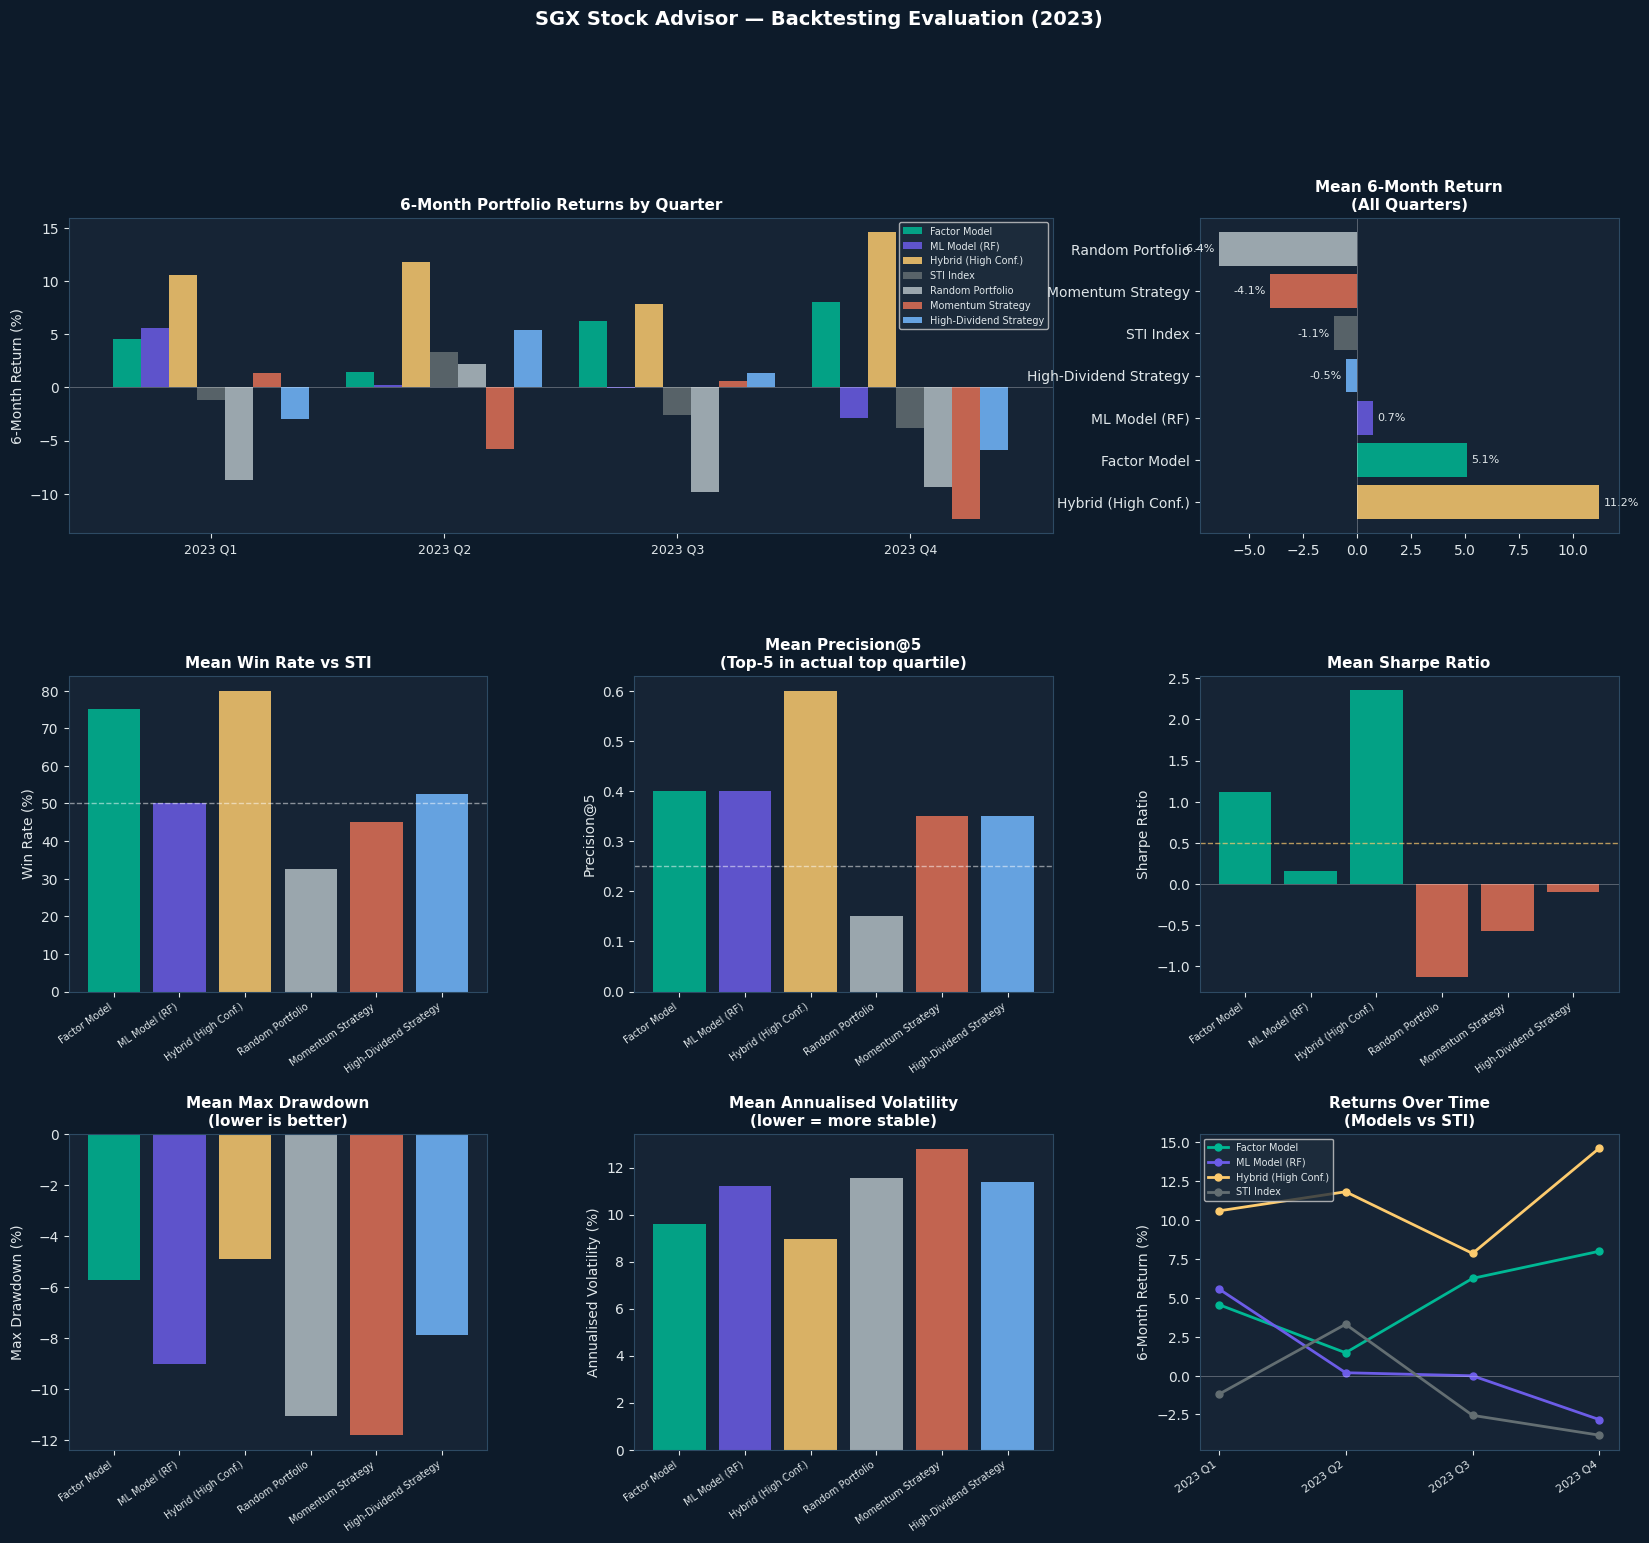

✓ Visualisation saved to data/backtesting/backtesting_results.png


In [6]:
# ============================================
# STEP 5: VISUALISATIONS
# ============================================

print("\n[Step 5] Generating visualisations...")

os.makedirs('data/backtesting', exist_ok=True)

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0d1b2a')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

PALETTE = {
    'Factor':   '#00b894',
    'ML':       '#6c5ce7',
    'Hybrid':   '#fdcb6e',
    'STI':      '#636e72',
    'Random':   '#b2bec3',
    'Momentum': '#e17055',
    'Dividend': '#74b9ff',
}

quarters = results_df['Quarter'].tolist()
x = np.arange(len(quarters))

# ---- Plot 1: 6-Month Returns by Quarter ----
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('#162435')
width = 0.12
offsets = np.linspace(-3, 3, 7) * width
for i, m in enumerate(['Factor', 'ML', 'Hybrid', 'STI',
                        'Random', 'Momentum', 'Dividend']):
    col = f'{m}_Return' if m != 'STI' else 'STI_Return'
    vals = results_df[col].values * 100
    bars = ax1.bar(x + offsets[i], vals, width,
                   label=DISPLAY_NAMES[m], color=PALETTE[m], alpha=0.85)

ax1.axhline(0, color='white', linewidth=0.5, alpha=0.4)
ax1.set_xticks(x)
ax1.set_xticklabels(quarters, color='#dfe6e9', fontsize=9)
ax1.set_ylabel('6-Month Return (%)', color='#dfe6e9')
ax1.set_title('6-Month Portfolio Returns by Quarter', color='white',
              fontweight='bold', fontsize=11)
ax1.legend(fontsize=7, loc='upper right',
           facecolor='#1e2d3d', labelcolor='#dfe6e9')
ax1.tick_params(colors='#dfe6e9')
ax1.spines[:].set_color('#2d4a63')
ax1.yaxis.label.set_color('#dfe6e9')

# ---- Plot 2: Mean Returns Comparison (horizontal bar) ----
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#162435')
mean_returns = {DISPLAY_NAMES[m]: results_df[
    f'{m}_Return' if m != 'STI' else 'STI_Return'].mean() * 100
    for m in MODELS}
sorted_items = sorted(mean_returns.items(), key=lambda x: x[1], reverse=True)
labels_sorted = [i[0] for i in sorted_items]
vals_sorted = [i[1] for i in sorted_items]
colors_bar = [PALETTE[next(k for k, v in DISPLAY_NAMES.items() if v == l)]
              for l in labels_sorted]
bars = ax2.barh(labels_sorted, vals_sorted, color=colors_bar, alpha=0.85)
ax2.axvline(0, color='white', linewidth=0.5, alpha=0.4)
for bar, val in zip(bars, vals_sorted):
    ax2.text(val + 0.2 if val >= 0 else val - 0.2,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right',
             color='#dfe6e9', fontsize=8)
ax2.set_title('Mean 6-Month Return\n(All Quarters)', color='white',
              fontweight='bold', fontsize=11)
ax2.tick_params(colors='#dfe6e9')
ax2.spines[:].set_color('#2d4a63')
ax2.set_facecolor('#162435')

# ---- Plot 3: Win Rate vs STI ----
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('#162435')
wr_models = ['Factor', 'ML', 'Hybrid', 'Random', 'Momentum', 'Dividend']
wr_means = [results_df[f'{m}_WinRate'].mean() * 100 for m in wr_models]
wr_colors = [PALETTE[m] for m in wr_models]
ax3.bar([DISPLAY_NAMES[m] for m in wr_models], wr_means,
        color=wr_colors, alpha=0.85)
ax3.axhline(50, color='white', linewidth=1, linestyle='--',
            alpha=0.5, label='50% baseline')
ax3.set_ylabel('Win Rate (%)', color='#dfe6e9')
ax3.set_title('Mean Win Rate vs STI', color='white',
              fontweight='bold', fontsize=11)
ax3.set_xticklabels([DISPLAY_NAMES[m] for m in wr_models],
                     rotation=35, ha='right', color='#dfe6e9', fontsize=7)
ax3.tick_params(colors='#dfe6e9')
ax3.spines[:].set_color('#2d4a63')

# ---- Plot 4: Precision@5 ----
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('#162435')
p5_models = ['Factor', 'ML', 'Hybrid', 'Random', 'Momentum', 'Dividend']
p5_means = [results_df[f'{m}_P5'].mean() for m in p5_models]
ax4.bar([DISPLAY_NAMES[m] for m in p5_models], p5_means,
        color=[PALETTE[m] for m in p5_models], alpha=0.85)
ax4.axhline(0.25, color='white', linewidth=1, linestyle='--',
            alpha=0.5, label='Random baseline (25%)')
ax4.set_ylabel('Precision@5', color='#dfe6e9')
ax4.set_title('Mean Precision@5\n(Top-5 in actual top quartile)',
              color='white', fontweight='bold', fontsize=11)
ax4.set_xticklabels([DISPLAY_NAMES[m] for m in p5_models],
                     rotation=35, ha='right', color='#dfe6e9', fontsize=7)
ax4.tick_params(colors='#dfe6e9')
ax4.spines[:].set_color('#2d4a63')

# ---- Plot 5: Sharpe Ratio ----
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#162435')
sharpe_models = ['Factor', 'ML', 'Hybrid', 'Random', 'Momentum', 'Dividend']
sharpe_means = [results_df[f'{m}_Sharpe'].mean() for m in sharpe_models]
colors_sharpe = ['#00b894' if v > 0 else '#e17055' for v in sharpe_means]
ax5.bar([DISPLAY_NAMES[m] for m in sharpe_models], sharpe_means,
        color=colors_sharpe, alpha=0.85)
ax5.axhline(0.5, color='#fdcb6e', linewidth=1, linestyle='--',
            alpha=0.7, label='Target: 0.5')
ax5.axhline(0, color='white', linewidth=0.5, alpha=0.4)
ax5.set_ylabel('Sharpe Ratio', color='#dfe6e9')
ax5.set_title('Mean Sharpe Ratio', color='white',
              fontweight='bold', fontsize=11)
ax5.set_xticklabels([DISPLAY_NAMES[m] for m in sharpe_models],
                     rotation=35, ha='right', color='#dfe6e9', fontsize=7)
ax5.tick_params(colors='#dfe6e9')
ax5.spines[:].set_color('#2d4a63')

# ---- Plot 6: Max Drawdown ----
ax6 = fig.add_subplot(gs[2, 0])
ax6.set_facecolor('#162435')
dd_models = ['Factor', 'ML', 'Hybrid', 'Random', 'Momentum', 'Dividend']
dd_means = [results_df[f'{m}_MaxDD'].mean() * 100 for m in dd_models]
ax6.bar([DISPLAY_NAMES[m] for m in dd_models], dd_means,
        color=[PALETTE[m] for m in dd_models], alpha=0.85)
ax6.set_ylabel('Max Drawdown (%)', color='#dfe6e9')
ax6.set_title('Mean Max Drawdown\n(lower is better)',
              color='white', fontweight='bold', fontsize=11)
ax6.set_xticklabels([DISPLAY_NAMES[m] for m in dd_models],
                     rotation=35, ha='right', color='#dfe6e9', fontsize=7)
ax6.tick_params(colors='#dfe6e9')
ax6.spines[:].set_color('#2d4a63')

# ---- Plot 7: Volatility ----
ax7 = fig.add_subplot(gs[2, 1])
ax7.set_facecolor('#162435')
vol_models = ['Factor', 'ML', 'Hybrid', 'Random', 'Momentum', 'Dividend']
vol_means = [results_df[f'{m}_Vol'].mean() * 100 for m in vol_models]
ax7.bar([DISPLAY_NAMES[m] for m in vol_models], vol_means,
        color=[PALETTE[m] for m in vol_models], alpha=0.85)
ax7.set_ylabel('Annualised Volatility (%)', color='#dfe6e9')
ax7.set_title('Mean Annualised Volatility\n(lower = more stable)',
              color='white', fontweight='bold', fontsize=11)
ax7.set_xticklabels([DISPLAY_NAMES[m] for m in vol_models],
                     rotation=35, ha='right', color='#dfe6e9', fontsize=7)
ax7.tick_params(colors='#dfe6e9')
ax7.spines[:].set_color('#2d4a63')

# ---- Plot 8: Quarterly returns line chart (Factor vs ML vs STI) ----
ax8 = fig.add_subplot(gs[2, 2])
ax8.set_facecolor('#162435')
for m, col in [('Factor', 'Factor_Return'), ('ML', 'ML_Return'),
               ('Hybrid', 'Hybrid_Return'), ('STI', 'STI_Return')]:
    ax8.plot(quarters, results_df[col] * 100,
             marker='o', label=DISPLAY_NAMES[m],
             color=PALETTE[m], linewidth=2, markersize=5)
ax8.axhline(0, color='white', linewidth=0.5, alpha=0.4)
ax8.set_ylabel('6-Month Return (%)', color='#dfe6e9')
ax8.set_title('Returns Over Time\n(Models vs STI)',
              color='white', fontweight='bold', fontsize=11)
ax8.set_xticklabels(quarters, rotation=35, ha='right',
                     color='#dfe6e9', fontsize=8)
ax8.legend(fontsize=7, facecolor='#1e2d3d', labelcolor='#dfe6e9')
ax8.tick_params(colors='#dfe6e9')
ax8.spines[:].set_color('#2d4a63')

plt.suptitle('SGX Stock Advisor — Backtesting Evaluation (2023)',
             color='white', fontsize=14, fontweight='bold', y=1.01)

plt.savefig('data/backtesting/backtesting_results.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1b2a')
plt.show()
print("✓ Visualisation saved to data/backtesting/backtesting_results.png")

In [7]:
# ============================================
# STEP 6: SAVE RESULTS AND FINAL SUMMARY
# ============================================

print("\n[Step 6] Saving results...")

# Save quarterly results
results_df.to_csv('data/backtesting/quarterly_results.csv', index=False)
print("✓ Saved: data/backtesting/quarterly_results.csv")

# Save summary table (re-generate without formatting for CSV)
summary_raw = []
for m in MODELS:
    ret_col = f'{m}_Return' if m != 'STI' else 'STI_Return'
    r = {
        'Strategy':         DISPLAY_NAMES[m],
        'Mean_6M_Return':   results_df[ret_col].mean(),
        'Std_6M_Return':    results_df[ret_col].std(),
    }
    for metric, col_suffix in [('WinRate', 'WinRate'), ('Sharpe', 'Sharpe'),
                                ('MaxDrawdown', 'MaxDD'), ('Volatility', 'Vol'),
                                ('Precision5', 'P5')]:
        col = f'{m}_{col_suffix}'
        r[f'Mean_{metric}'] = results_df[col].mean() if col in results_df else np.nan
    summary_raw.append(r)

pd.DataFrame(summary_raw).to_csv(
    'data/backtesting/summary_metrics.csv', index=False)
print("✓ Saved: data/backtesting/summary_metrics.csv")

# Save t-test results
pd.DataFrame(ttest_results).to_csv(
    'data/backtesting/ttest_results.csv', index=False)
print("✓ Saved: data/backtesting/ttest_results.csv")

# ---- FINAL SUMMARY ----
print("\n" + "=" * 60)
print("TASK 20 COMPLETE — BACKTESTING EVALUATION")
print("=" * 60)

print("\n📊 PERFORMANCE SUMMARY:")
print(f"  Factor Model mean return:   {results_df['Factor_Return'].mean():.2%}")
print(f"  ML Model mean return:       {results_df['ML_Return'].mean():.2%}")
print(f"  Hybrid mean return:         {results_df['Hybrid_Return'].mean():.2%}")
print(f"  STI Index mean return:      {results_df['STI_Return'].mean():.2%}")
print(f"  Random mean return:         {results_df['Random_Return'].mean():.2%}")
print(f"  Momentum mean return:       {results_df['Momentum_Return'].mean():.2%}")
print(f"  High-Dividend mean return:  {results_df['Dividend_Return'].mean():.2%}")

print("\n🎯 HYPOTHESIS RESULTS:")
print(f"  H1 (Factor ≥ Dividend + 5%): {status_h1}  (Δ = {diff_h1:.2%})")
print(f"  H2 (ML Precision@5 ≥ 30%):  {status_h2}  "
      f"({results_df['ML_P5'].mean():.2%})")

print("\n📁 FILES SAVED:")
print("  - data/backtesting/quarterly_results.csv")
print("  - data/backtesting/summary_metrics.csv")
print("  - data/backtesting/ttest_results.csv")
print("  - data/backtesting/backtesting_results.png")

print("\n📋 LIMITATIONS ACKNOWLEDGED:")
print("  - Assumes zero transaction costs (no slippage, no brokerage fees)")
print("  - Survivorship bias: uses only stocks that survived to 2024")
print("  - Small sample: only 4 quarterly snapshots in 2023")
print("  - STI proxy used if ^STI price file is unavailable")
print("  - Fundamental data is point-in-time (from yfinance, no historical snapshots)")

print("\n" + "=" * 60)


[Step 6] Saving results...
✓ Saved: data/backtesting/quarterly_results.csv
✓ Saved: data/backtesting/summary_metrics.csv
✓ Saved: data/backtesting/ttest_results.csv

TASK 20 COMPLETE — BACKTESTING EVALUATION

📊 PERFORMANCE SUMMARY:
  Factor Model mean return:   5.08%
  ML Model mean return:       0.73%
  Hybrid mean return:         11.23%
  STI Index mean return:      -1.07%
  Random mean return:         -6.42%
  Momentum mean return:       -4.05%
  High-Dividend mean return:  -0.50%

🎯 HYPOTHESIS RESULTS:
  H1 (Factor ≥ Dividend + 5%): ✓ SUPPORTED  (Δ = 5.58%)
  H2 (ML Precision@5 ≥ 30%):  ✓ SUPPORTED  (40.00%)

📁 FILES SAVED:
  - data/backtesting/quarterly_results.csv
  - data/backtesting/summary_metrics.csv
  - data/backtesting/ttest_results.csv
  - data/backtesting/backtesting_results.png

📋 LIMITATIONS ACKNOWLEDGED:
  - Assumes zero transaction costs (no slippage, no brokerage fees)
  - Survivorship bias: uses only stocks that survived to 2024
  - Small sample: only 4 quarterly s